In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import glob

image_paths_train = glob.glob('/content/drive/MyDrive/ImageSegmentation_OCT/OCT_Dataset/img_dir/TRAINING*.tif')
print(image_paths_train)

image_paths_test = glob.glob('/content/drive/MyDrive/ImageSegmentation_OCT/OCT_Dataset/ann_dir/TRAINING*.tif')
print(image_paths_test)



['/content/drive/MyDrive/ImageSegmentation_OCT/OCT_Dataset/img_dir/TRAINING6.tif', '/content/drive/MyDrive/ImageSegmentation_OCT/OCT_Dataset/img_dir/TRAINING1.tif', '/content/drive/MyDrive/ImageSegmentation_OCT/OCT_Dataset/img_dir/TRAINING4.tif', '/content/drive/MyDrive/ImageSegmentation_OCT/OCT_Dataset/img_dir/TRAINING9.tif', '/content/drive/MyDrive/ImageSegmentation_OCT/OCT_Dataset/img_dir/TRAINING8.tif', '/content/drive/MyDrive/ImageSegmentation_OCT/OCT_Dataset/img_dir/TRAINING5.tif', '/content/drive/MyDrive/ImageSegmentation_OCT/OCT_Dataset/img_dir/TRAINING2.tif', '/content/drive/MyDrive/ImageSegmentation_OCT/OCT_Dataset/img_dir/TRAINING10.tif', '/content/drive/MyDrive/ImageSegmentation_OCT/OCT_Dataset/img_dir/TRAINING3.tif', '/content/drive/MyDrive/ImageSegmentation_OCT/OCT_Dataset/img_dir/TRAINING7.tif']
['/content/drive/MyDrive/ImageSegmentation_OCT/OCT_Dataset/ann_dir/TRAINING1.tif', '/content/drive/MyDrive/ImageSegmentation_OCT/OCT_Dataset/ann_dir/TRAINING10.tif', '/content/dr

In [ ]:
import cv2, os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


import imageio.v3 as iio
from sklearn.metrics import confusion_matrix, precision_score, recall_score, accuracy_score
import pandas as pd
from skimage.transform import resize

from skimage import io, data, segmentation,feature
from sklearn.cluster import KMeans
from skimage.color import label2rgb, rgb2hsv, rgb2lab, rgb2gray
from skimage import  img_as_ubyte,img_as_float
from sklearn.cluster import MeanShift, estimate_bandwidth
from sklearn.feature_extraction.image import grid_to_graph
from sklearn.cluster import MeanShift, estimate_bandwidth
from skimage import graph
from skimage.morphology import disk
from skimage.segmentation import watershed,flood, flood_fill
from skimage.filters import rank
from scipy import ndimage as ndi
from skimage.util import random_noise
from skimage.morphology import square, footprint_rectangle
from skimage.filters import gaussian, laplace, rank, median
from skimage import exposure, filters, morphology, measure, util
from skimage.restoration import denoise_nl_means, denoise_bilateral, estimate_sigma
from scipy.ndimage import binary_fill_holes

FILTERING -

1)Median
2)Bilateral
3)CLAHE (contrast increases)
4)Croping perhaps??
5)Normalization of values

In [ ]:
for i, path in enumerate(image_paths_train):
    print(f"{i+1}. {os.path.basename(path)}")



1. TRAINING5.tif
2. TRAINING2.tif
3. TRAINING1.tif
4. TRAINING9.tif
5. TRAINING6.tif
6. TRAINING8.tif
7. TRAINING10.tif
8. TRAINING7.tif
9. TRAINING3.tif
10. TRAINING4.tif


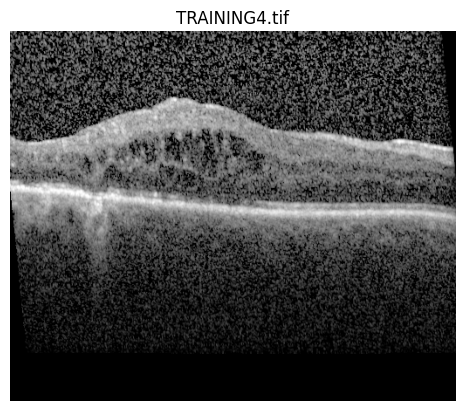

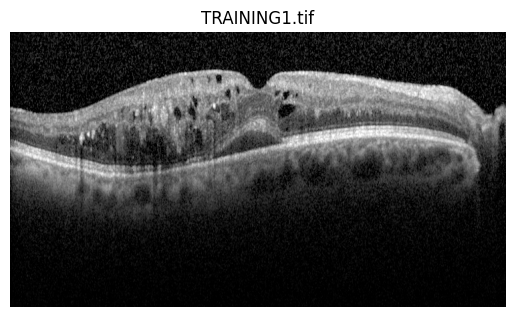

In [ ]:
train_1ex = image_paths_train[2]
train_2ex = image_paths_train[1]

img1 = io.imread(train_1ex)
img2 = io.imread(train_2ex)
plt.imshow(img1, cmap='gray')
plt.title(os.path.basename(image_paths_train[2]))
plt.axis('off')
plt.show()

plt.imshow(img2, cmap='gray')
plt.title(os.path.basename(image_paths_train[1]))
plt.axis('off')
plt.show()

Applied Median Filter


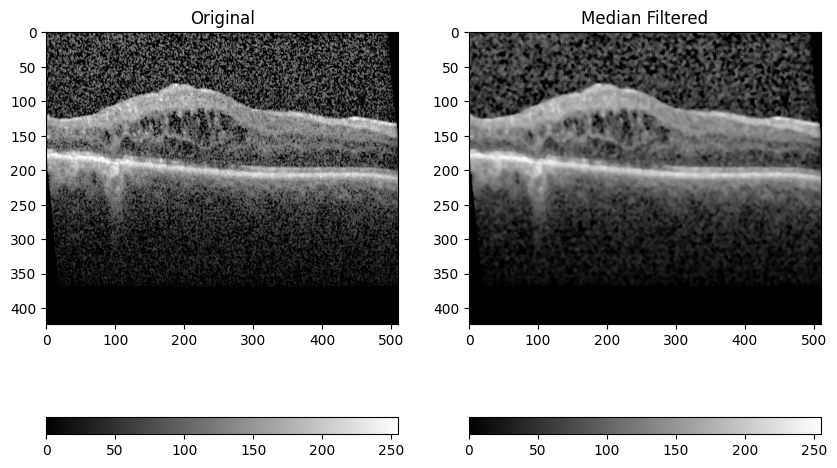

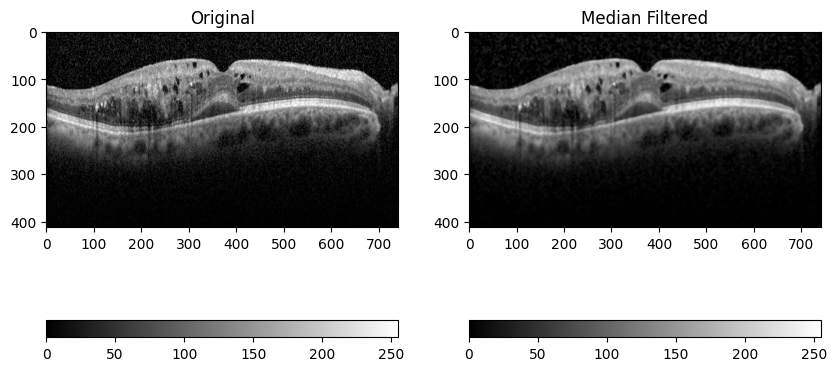

In [53]:
def apply_median_filter(img):
    median_img = median(img, footprint_rectangle((5, 5)))
    return median_img

median_img1 = median(img1, footprint_rectangle((5, 5)))
fig = plt.figure(figsize=(10, 8))
plt.subplot(1,2,1), plt.imshow(img1, cmap='gray'), plt.title('Original')
plt.clim(0,255)
c = plt.colorbar(orientation = 'horizontal')
plt.subplot(1,2,2), plt.imshow(median_img1, cmap='gray'), plt.title('Median Filtered')
plt.clim(0,255)
c = plt.colorbar(orientation = 'horizontal')
plt.show()

median_img2 = median(img2, footprint_rectangle((5, 5)))
fig = plt.figure(figsize=(10, 8))
plt.subplot(1,2,1), plt.imshow(img2, cmap='gray'), plt.title('Original')
plt.clim(0,255)
c = plt.colorbar(orientation = 'horizontal')
plt.subplot(1,2,2), plt.imshow(median_img2, cmap='gray'), plt.title('Median Filtered')
plt.clim(0,255)
c = plt.colorbar(orientation = 'horizontal')
plt.show()


Overlaped Median Filtered Image With Bilateral Filter


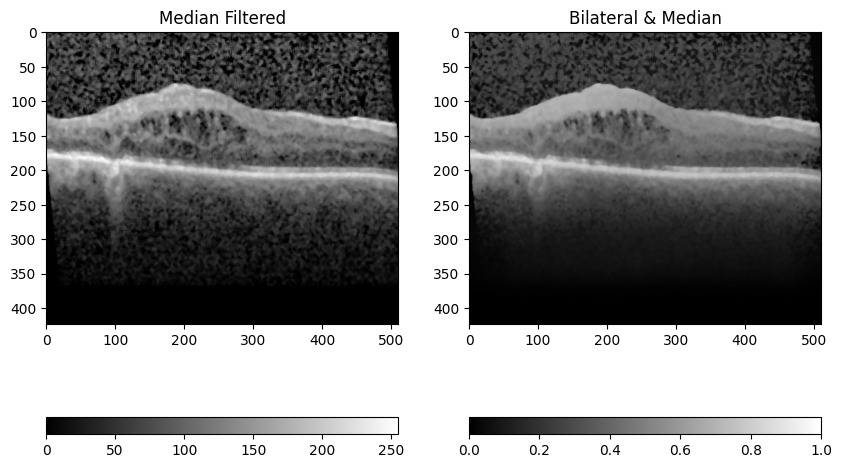

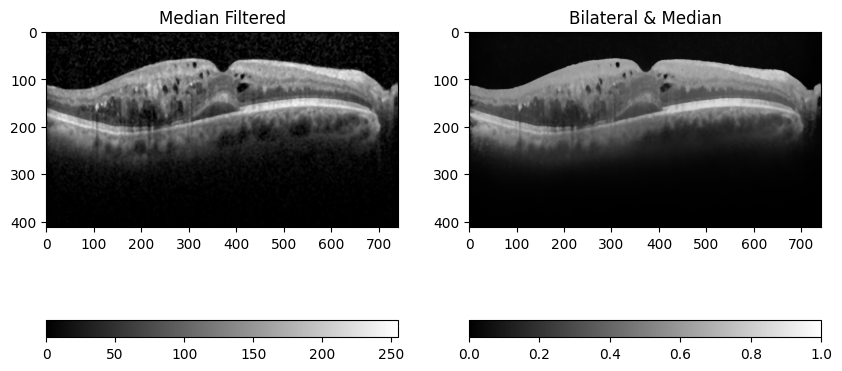

In [ ]:
def apply_bilateral_filter(median_img, sigma_color=0.1, sigma_spatial=15):
    bilateral_img = denoise_bilateral(median_img, sigma_color=sigma_color, sigma_spatial=sigma_spatial)
    return bilateral_img


bilateral_img1 = denoise_bilateral(median_img1, sigma_color=0.1, sigma_spatial=15)
fig = plt.figure(figsize=(10, 8))
plt.subplot(1,2,1), plt.imshow(median_img1, cmap='gray'), plt.title('Median Filtered')
plt.clim(0,255)
c = plt.colorbar(orientation = 'horizontal')
plt.subplot(1,2,2), plt.imshow(bilateral_img1, cmap='gray'), plt.title('Bilateral & Median')
plt.clim(0,1)
c = plt.colorbar(orientation = 'horizontal')
plt.show()

bilateral_img2 = denoise_bilateral(median_img2, sigma_color=0.1, sigma_spatial=15)
fig = plt.figure(figsize=(10, 8))
plt.subplot(1,2,1), plt.imshow(median_img2, cmap='gray'), plt.title('Median Filtered')
plt.clim(0,255)
c = plt.colorbar(orientation = 'horizontal')
plt.subplot(1,2,2), plt.imshow(bilateral_img2, cmap='gray'), plt.title('Bilateral & Median')
plt.clim(0,1)
c = plt.colorbar(orientation = 'horizontal')
plt.show()

Contrast enhancement using CLAHE (Contrast Limited Adaptive Histogram Equalization)

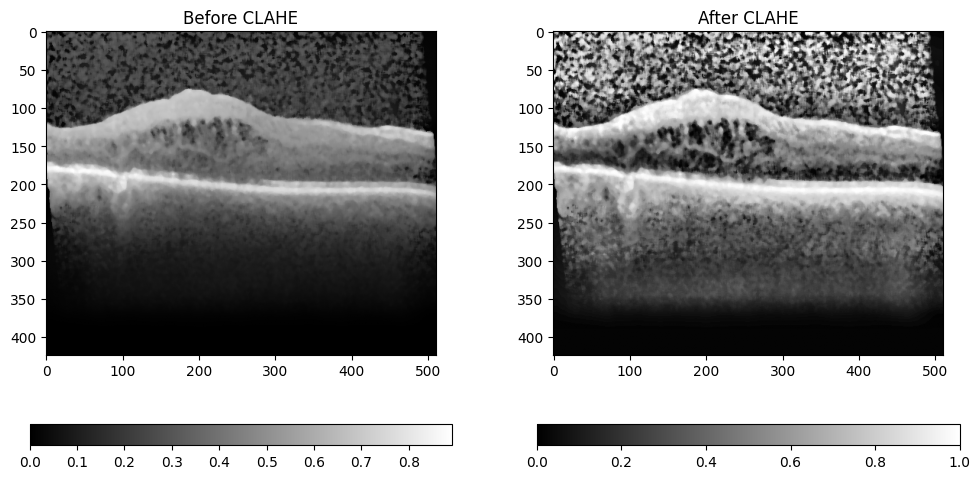

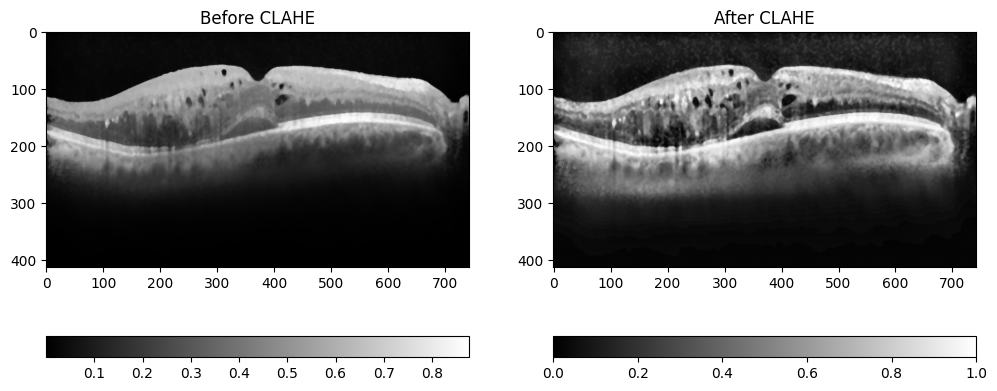

In [ ]:
def apply_clahe(bilateral_img, clip_limit=0.02):
    clahe_img = exposure.equalize_adapthist(bilateral_img, clip_limit=clip_limit)
    return clahe_img


#doesen't seem the best though

clahe_img1 = exposure.equalize_adapthist(bilateral_img1, clip_limit=0.02)
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(bilateral_img1, cmap='gray')
plt.title('Before CLAHE')
c = plt.colorbar(orientation = 'horizontal')
plt.axis('on')
plt.subplot(1,2,2)
plt.imshow(clahe_img1, cmap='gray')
plt.title('After CLAHE')
c = plt.colorbar(orientation = 'horizontal')
plt.axis('on')
plt.show()

clahe_img2 = exposure.equalize_adapthist(bilateral_img2, clip_limit=0.02)
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(bilateral_img2, cmap='gray')
plt.title('Before CLAHE')
c = plt.colorbar(orientation = 'horizontal')
plt.axis('on')
plt.subplot(1,2,2)
plt.imshow(clahe_img2, cmap='gray')
plt.title('After CLAHE')
c = plt.colorbar(orientation = 'horizontal')
plt.axis('on')
plt.show()

Normalization

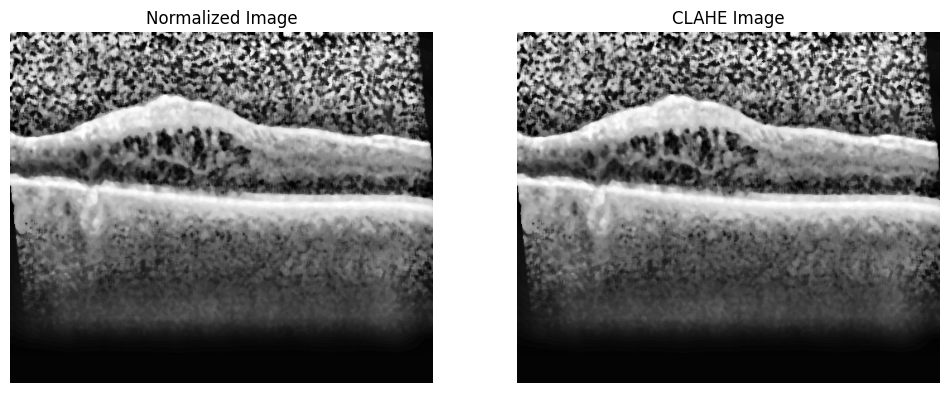

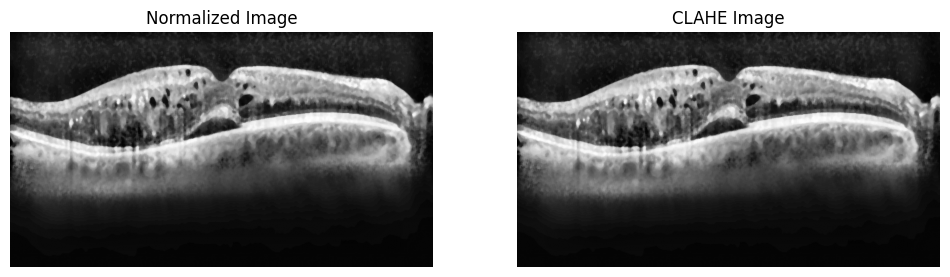

In [ ]:
def normalize_image(clahe_img):
    img_norm = (clahe_img - np.min(clahe_img)) / (np.max(clahe_img) - np.min(clahe_img))
    return img_norm

#need to see more if it helps or not
img_norm1 = (clahe_img1 - np.min(clahe_img1)) / (np.max(clahe_img1) - np.min(clahe_img1))
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(img_norm1, cmap='grey')
plt.title('Normalized Image')
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(clahe_img1, cmap='gray')
plt.title('CLAHE Image')
plt.axis('off')
plt.show()

img_norm2 = (clahe_img2 - np.min(clahe_img2)) / (np.max(clahe_img2) - np.min(clahe_img2))
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(img_norm2, cmap='grey')
plt.title('Normalized Image')
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(clahe_img2, cmap='gray')
plt.title('CLAHE Image')
plt.axis('off')
plt.show()



  SEGMENTATION-
  1)Thresholding Global(Otsu)
  2)Region Growing
  3)Watershed
  4)K-means
  

In [ ]:
#Postprocessing function
def post_process_mask(mask, min_area=100, close_disk=1):
    # clean small objects and close small holes
    mask = morphology.remove_small_objects(mask.astype(bool), min_size=min_area)
    mask = morphology.remove_small_holes(mask, area_threshold=min_area)
    mask = morphology.binary_closing(mask, morphology.disk(close_disk))
    return mask.astype(bool)



Thresholding Otsu

(np.float64(-0.5), np.float64(741.5), np.float64(411.5), np.float64(-0.5))

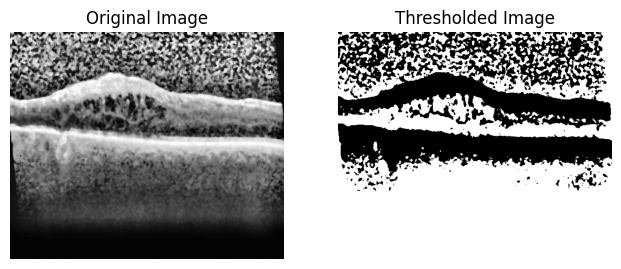

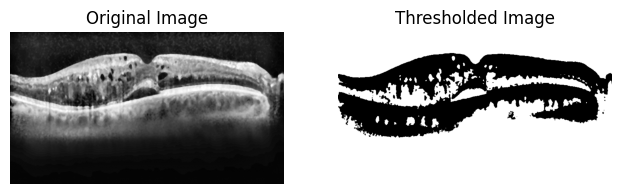

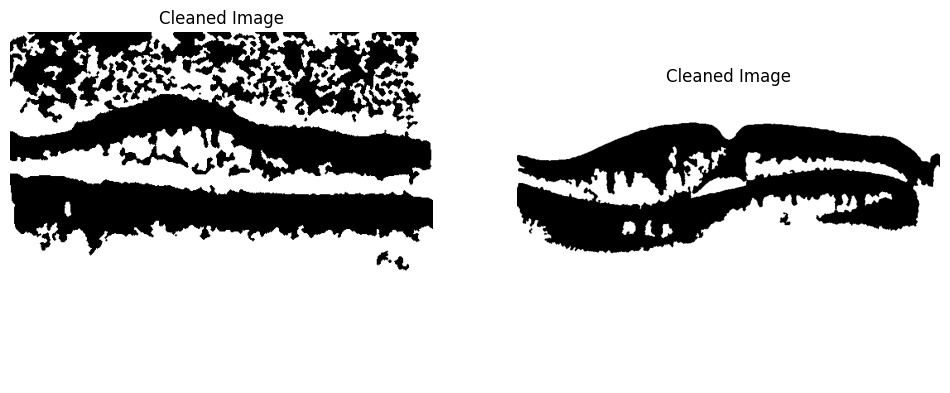

In [ ]:
def segment_otsu(img_norm):

    # Calculate Otsu threshold
    thresh_val = filters.threshold_otsu(img_norm)

    # Create binary mask
    binary_mask = img_norm < thresh_val

    return binary_mask


thresh_val1 = filters.threshold_otsu(img_norm1)
binary_img1 = img_norm1 < thresh_val1
cleaned_img1 = morphology.remove_small_objects(binary_img1, min_size=100)

plt.figure(figsize=(12,6))
plt.subplot(1,3,1)
plt.title('Original Image')
plt.imshow(img_norm1, cmap='gray')
plt.axis('off')
plt.subplot(1,3,2)
plt.title('Thresholded Image')
plt.imshow(binary_img1, cmap='gray')
plt.axis('off')

thresh_val2 = filters.threshold_otsu(img_norm2)
binary_img2 = img_norm2 < thresh_val2
cleaned_img2 = morphology.remove_small_objects(binary_img2, min_size=100)

plt.figure(figsize=(12,6))
plt.subplot(1,3,1)
plt.title('Original Image')
plt.imshow(img_norm2, cmap='gray')
plt.axis('off')
plt.subplot(1,3,2)
plt.title('Thresholded Image')
plt.imshow(binary_img2, cmap='gray')
plt.axis('off')

mask_img1 = post_process_mask(cleaned_img1, min_area=100, close_disk=1)
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(mask_img1, cmap='gray')
plt.title('Cleaned Image')
plt.axis('off')

mask_img2 = post_process_mask(cleaned_img2, min_area=200, close_disk=1)
plt.subplot(1,2,2)
plt.imshow(mask_img2, cmap='gray')
plt.title('Cleaned Image')
plt.axis('off')

K-Means Segmentation

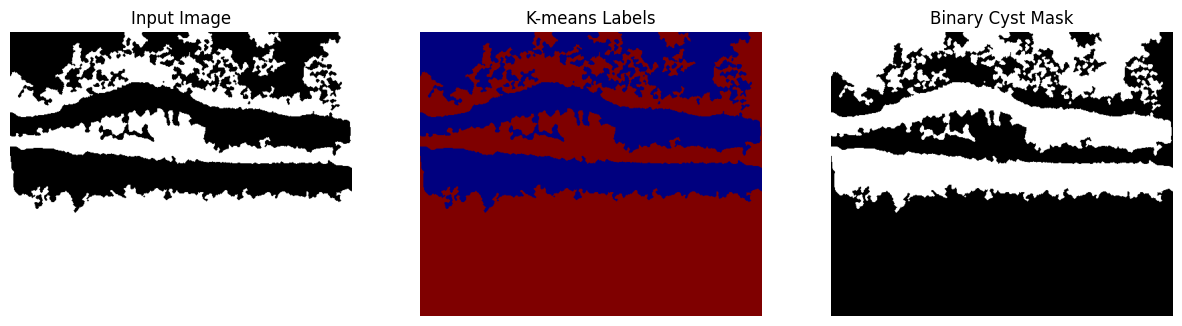

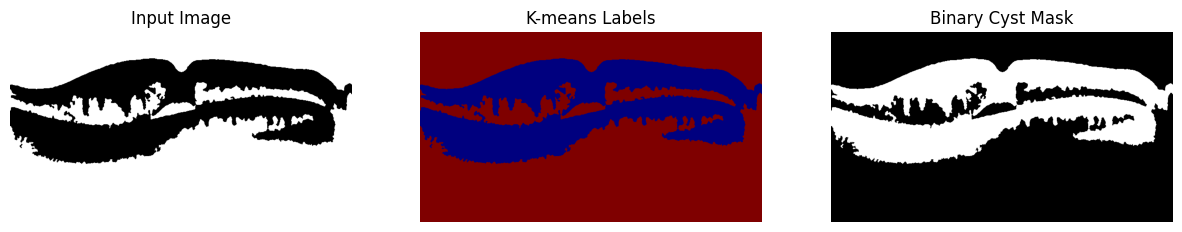

In [ ]:
def segment_kmeans(mask_img, n_clusters=2, random_state=42):

    # Flatten image for K-means (reshape to (num_pixels, 1))
    img_flat = mask_img.reshape(-1, 1)

    # Run K-means clustering
    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state)
    labels = kmeans.fit_predict(img_flat)

    # Reshape labels back to image shape
    kmeans_mask = labels.reshape(mask_img.shape)

    # Decide which label is cyst (usually the darker cluster)
    # Compare cluster centers: cluster with lower intensity = cyst
    label_cyst = 0 if kmeans.cluster_centers_[0] < kmeans.cluster_centers_[1] else 1

    # Create binary mask (cyst pixels = True)
    cyst_mask = (kmeans_mask == label_cyst).astype(np.uint8)

    return cyst_mask


# img should be your preprocessed (e.g., denoised/normalized) grayscale image
img_flat = mask_img1.reshape(-1, 1)  # shape (num_pixels, 1)

# Run K-means with 2 clusters (cyst/background)
kmeans = KMeans(n_clusters=2, random_state=42)
labels = kmeans.fit_predict(img_flat)

# Reshape labels to image
kmeans_mask1 = labels.reshape(mask_img1.shape)

# Decide which label is cyst (usually the darker cluster)
label_cyst = 0 if kmeans.cluster_centers_[0] < kmeans.cluster_centers_[1] else 1
cyst_mask1 = (kmeans_mask1 == label_cyst).astype(np.uint8)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(mask_img1, cmap='gray')
plt.title('Input Image')
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(kmeans_mask1, cmap='jet')
plt.title('K-means Labels')
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(cyst_mask1, cmap='gray')
plt.title('Binary Cyst Mask')
plt.axis('off')
plt.show()

# img should be your preprocessed (e.g., denoised/normalized) grayscale image
img_flat = mask_img2.reshape(-1, 1)  # shape (num_pixels, 1)

# Run K-means with 2 clusters (cyst/background)
kmeans = KMeans(n_clusters=2, random_state=42)
labels = kmeans.fit_predict(img_flat)

# Reshape labels to image
kmeans_mask2 = labels.reshape(mask_img2.shape)

# Decide which label is cyst (usually the darker cluster)
label_cyst = 0 if kmeans.cluster_centers_[0] < kmeans.cluster_centers_[1] else 1
cyst_mask2 = (kmeans_mask2 == label_cyst).astype(np.uint8)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(mask_img2, cmap='gray')
plt.title('Input Image')
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(kmeans_mask2, cmap='jet')
plt.title('K-means Labels')
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(cyst_mask2, cmap='gray')
plt.title('Binary Cyst Mask')
plt.axis('off')
plt.show()


Post-processing for kmeans

/tmp/ipython-input-2516233652.py:10: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  post_processed_Kimg1 = morphology.remove_small_objects(cyst_mask1, min_size=500)


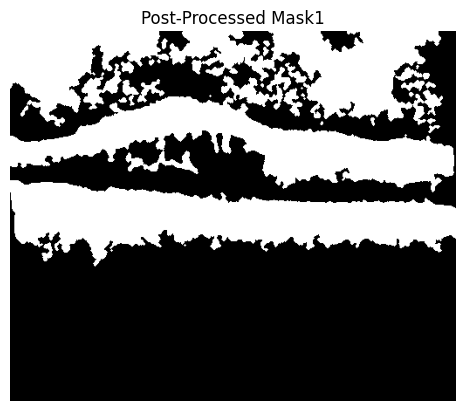

/tmp/ipython-input-2516233652.py:18: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  post_processed_Kimg2 = morphology.remove_small_objects(cyst_mask2, min_size=500)


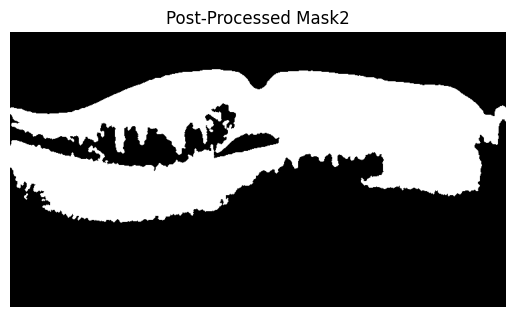

In [ ]:

def post_process_kmeans(cyst_mask, min_size=500):

    # Remove small objects
    post_processed = morphology.remove_small_objects(cyst_mask.astype(bool), min_size=min_size)

    # Fill holes inside cyst regions
    post_processed = binary_fill_holes(post_processed)

    return post_processed
post_processed_Kimg1 = morphology.remove_small_objects(cyst_mask1, min_size=500)
post_processed_Kimg1 = binary_fill_holes(post_processed_Kimg1)

plt.imshow(post_processed_Kimg1, cmap='gray')
plt.title('Post-Processed Mask1')
plt.axis('off')
plt.show()

post_processed_Kimg2 = morphology.remove_small_objects(cyst_mask2, min_size=500)
post_processed_Kimg2 = binary_fill_holes(post_processed_Kimg2)

plt.imshow(post_processed_Kimg2, cmap='gray')
plt.title('Post-Processed Mask2')
plt.axis('off')
plt.show()


Sorting & Pairing Train and Ann Images

In [ ]:
print(f"Found {len(image_paths_train)} training images")
print(f"Found {len(image_paths_test)} annotation masks")

# Create dictionaries for easy matching by basename
train_dict = {os.path.basename(f): f for f in image_paths_train}
test_dict = {os.path.basename(f): f for f in image_paths_test}

# Match them: find common basenames
common_names = sorted(set(train_dict.keys()) & set(test_dict.keys()))

# Build paired lists
paired_image_paths = [train_dict[name] for name in common_names]
paired_mask_paths = [test_dict[name] for name in common_names]

print(f"\nMatched {len(common_names)} image-mask pairs")
print("Sample pairs:")
for i in range(min(10, len(common_names))):
    print(f"  Image: {os.path.basename(paired_image_paths[i])}")
    print(f"  Mask:  {os.path.basename(paired_mask_paths[i])}")
    print()

# Now use paired_image_paths and paired_mask_paths for your workflow


Found 10 training images
Found 10 annotation masks

Matched 10 image-mask pairs
Sample pairs:
  Image: TRAINING1.tif
  Mask:  TRAINING1.tif

  Image: TRAINING10.tif
  Mask:  TRAINING10.tif

  Image: TRAINING2.tif
  Mask:  TRAINING2.tif

  Image: TRAINING3.tif
  Mask:  TRAINING3.tif

  Image: TRAINING4.tif
  Mask:  TRAINING4.tif

  Image: TRAINING5.tif
  Mask:  TRAINING5.tif

  Image: TRAINING6.tif
  Mask:  TRAINING6.tif

  Image: TRAINING7.tif
  Mask:  TRAINING7.tif

  Image: TRAINING8.tif
  Mask:  TRAINING8.tif

  Image: TRAINING9.tif
  Mask:  TRAINING9.tif



In [ ]:
#Filters Pipeline

def preprocess_pipeline(img):

    # Step 1: Median filter
    median_img = apply_median_filter(img)

    # Step 2: Bilateral filter
    bilateral_img = apply_bilateral_filter(median_img)

    # Step 3: CLAHE
    clahe_img = apply_clahe(bilateral_img)

    # Step 4: Normalization
    img_norm = normalize_image(clahe_img)

    return img_norm

In [ ]:
#EVALUATION METRICS FUNCTIONS


def dice_coefficient(y_true, y_pred):
    intersection = np.sum(y_true * y_pred)
    return 2. * intersection / (np.sum(y_true) + np.sum(y_pred) + 1e-7)

def mean_iou(y_true, y_pred):

    intersection = np.logical_and(y_true, y_pred).sum()
    union = np.logical_or(y_true, y_pred).sum()
    return intersection / (union + 1e-7)

def evaluate_segmentation(gt_mask, pred_mask):

    y_true = gt_mask.flatten().astype(int)
    y_pred = pred_mask.flatten().astype(int)

    dice = dice_coefficient(y_true, y_pred)
    miou = mean_iou(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    accuracy = accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)

    return {
        'dice': dice,
        'iou': miou,
        'precision': precision,
        'recall': recall,
        'accuracy': accuracy,
        'confusion_matrix': cm
    }


In [ ]:
# BATCH EVALUATION LOOP


def batch_evaluate_algorithms(paired_image_paths, paired_mask_paths):

    results = {
        'Otsu': [],
        'K-means': [],

    }

    print(f"\nEvaluating {len(paired_image_paths)} images...\n")
    print("="*70)

    for idx, (img_path, mask_path) in enumerate(zip(paired_image_paths, paired_mask_paths)):
        img_name = os.path.basename(img_path)
        print(f"Processing [{idx+1}/{len(paired_image_paths)}]: {img_name}")

        try:
            # Load image and ground truth
            img = iio.imread(img_path)
            gt_mask = iio.imread(mask_path)
               # ===== INVERT GROUND TRUTH (FIX!) =====
            gt_mask = gt_mask == 0  # Invert: black becomes white (cysts=True)

            # ===== CONVERT GROUND TRUTH TO GRAYSCALE IF RGB =====
            if len(gt_mask.shape) == 3:
                print(f"  Converting RGB mask to grayscale: {gt_mask.shape}")
                gt_mask = gt_mask[:, :, 0]  # Take first channel

            # ===== CONVERT IMAGE TO GRAYSCALE IF RGB =====
            if len(img.shape) == 3:
                print(f"  Converting RGB image to grayscale: {img.shape}")
                img = img[:, :, 0]  # Take first channel

            # ===== RESIZE MASK TO MATCH IMAGE DIMENSIONS =====
            if img.shape != gt_mask.shape:
                print(f"   Resizing mask from {gt_mask.shape} to {img.shape}")
                gt_mask = resize(gt_mask, img.shape, order=0, preserve_range=True, anti_aliasing=False) > 0.5

            # Preprocess using your pipeline
            img_norm = preprocess_pipeline(img)


            # ===== OTSU =====
            try:
                binary_otsu = segment_otsu(img_norm)
                cleaned_otsu = post_process_mask(binary_otsu, min_area=100, close_disk=2) ## CHANGES HERE 100,2
                metrics_otsu = evaluate_segmentation(gt_mask, cleaned_otsu)
                results['Otsu'].append(metrics_otsu)
                print(f"   Otsu - Dice: {metrics_otsu['dice']:.3f}, IoU: {metrics_otsu['iou']:.3f}")
            except Exception as e:
                print(f"   Otsu failed: {e}")
                results['Otsu'].append(None)

            # ===== K-MEANS =====
            try:
                cyst_kmeans = segment_kmeans(img_norm)
                cleaned_kmeans = post_process_kmeans(cyst_kmeans, min_size=100)
                metrics_kmeans = evaluate_segmentation(gt_mask, cleaned_kmeans)
                results['K-means'].append(metrics_kmeans)
                print(f"   K-means - Dice: {metrics_kmeans['dice']:.3f}, IoU: {metrics_kmeans['iou']:.3f}")
            except Exception as e:
                print(f"   K-means failed: {e}")
                results['K-means'].append(None)

            print()

        except Exception as e:
            print(f"   Error loading image: {e}\n")
            results['Otsu'].append(None)
            results['K-means'].append(None)


    print("="*70)
    return results

In [ ]:
# SUMMARIZE RESULTS


def summarize_results(results):

    summary_data = []

    print("\n" + "="*70)
    print("  EVALUATION SUMMARY - ALL ALGORITHMS")
    print("="*70)

    for algo_name, metrics_list in results.items():
        # Filter out None values
        valid_metrics = [m for m in metrics_list if m is not None]

        if len(valid_metrics) == 0:
            print(f"\n{algo_name}: No valid results")
            continue

        # Extract metric arrays
        dice_scores = [m['dice'] for m in valid_metrics]
        iou_scores = [m['iou'] for m in valid_metrics]
        precision_scores = [m['precision'] for m in valid_metrics]
        recall_scores = [m['recall'] for m in valid_metrics]
        accuracy_scores = [m['accuracy'] for m in valid_metrics]

        # Calculate statistics
        summary_data.append({
            'Algorithm': algo_name,
            'Dice_Mean': np.mean(dice_scores),
            'Dice_Std': np.std(dice_scores),
            'IoU_Mean': np.mean(iou_scores),
            'IoU_Std': np.std(iou_scores),
            'Precision_Mean': np.mean(precision_scores),
            'Recall_Mean': np.mean(recall_scores),
            'Accuracy_Mean': np.mean(accuracy_scores),
            'Num_Images': len(valid_metrics)
        })

        # Print formatted results
        print(f"\n{algo_name} (n={len(valid_metrics)} images):")
        print(f"  Dice:      {np.mean(dice_scores):.4f} \u00b1 {np.std(dice_scores):.4f}")
        print(f"  IoU:       {np.mean(iou_scores):.4f} \u00b1 {np.std(iou_scores):.4f}")
        print(f"  Precision: {np.mean(precision_scores):.4f}")
        print(f"  Recall:    {np.mean(recall_scores):.4f}")
        print(f"  Accuracy:  {np.mean(accuracy_scores):.4f}")

    print("\n" + "="*70 + "\n")

    # Create DataFrame
    summary_df = pd.DataFrame(summary_data)
    return summary_df


# RUN EVALUATION
# Run the evaluation
results = batch_evaluate_algorithms(paired_image_paths, paired_mask_paths)

# Generate summary
summary_df = summarize_results(results)

# Set the 'Algorithm' column as the index for easier lookup in plotting functions
summary_df = summary_df.set_index('Algorithm')

# Display summary table
print("\nSummary Table:")
print(summary_df.to_string(index=True))

# Save to CSV
summary_df.to_csv('segmentation_evaluation_summary.csv', index=True)
print("\n\u2713 Summary saved to 'segmentation_evaluation_summary.csv'")


Evaluating 10 images...

Processing [1/10]: TRAINING1.tif
  Converting RGB mask to grayscale: (412, 742, 3)
   Otsu - Dice: 0.822, IoU: 0.697
   K-means - Dice: 0.821, IoU: 0.696

Processing [2/10]: TRAINING10.tif
  Converting RGB mask to grayscale: (428, 772, 3)
   Otsu - Dice: 0.812, IoU: 0.683
   K-means - Dice: 0.812, IoU: 0.684

Processing [3/10]: TRAINING2.tif
  Converting RGB mask to grayscale: (415, 766, 3)
   Otsu - Dice: 0.789, IoU: 0.652
   K-means - Dice: 0.804, IoU: 0.672

Processing [4/10]: TRAINING3.tif
  Converting RGB mask to grayscale: (426, 716, 3)
   Otsu - Dice: 0.810, IoU: 0.681
   K-means - Dice: 0.809, IoU: 0.679

Processing [5/10]: TRAINING4.tif
  Converting RGB mask to grayscale: (424, 511, 3)
   Otsu - Dice: 0.780, IoU: 0.640
   K-means - Dice: 0.777, IoU: 0.636

Processing [6/10]: TRAINING5.tif
  Converting RGB mask to grayscale: (432, 755, 3)
   Otsu - Dice: 0.760, IoU: 0.613
   K-means - Dice: 0.816, IoU: 0.690

Processing [7/10]: TRAINING6.tif
  Converti

In [ ]:

# Set publication-quality plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


# FIGURE 1: ALGORITHM PERFORMANCE COMPARISON (BAR CHART)

def plot_algorithm_comparison(summary_df, save_path='figure1_algorithm_comparison.png'):
    """
    Create bar chart comparing Otsu and K-means across all metrics

    Parameters:
    -----------
    summary_df : DataFrame
        Output from generate_summary_report()
    save_path : str
        Where to save the figure
    """
    # Extract mean values for both algorithms
    metrics = ['Dice_Mean', 'IoU_Mean', 'Precision_Mean', 'Recall_Mean', 'Accuracy_Mean']
    metric_labels = ['Dice\nCoefficient', 'IoU', 'Precision', 'Recall', 'Accuracy']

    otsu_values = summary_df.loc['Otsu', metrics].values
    kmeans_values = summary_df.loc['K-means', metrics].values

    # Create bar chart
    x = np.arange(len(metrics))
    width = 0.35

    fig, ax = plt.subplots(figsize=(12, 6))
    bars1 = ax.bar(x - width/2, otsu_values, width, label='Otsu', color='#3498db', edgecolor='black')
    bars2 = ax.bar(x + width/2, kmeans_values, width, label='K-means', color='#e74c3c', edgecolor='black')

    # Customize plot
    ax.set_xlabel('Evaluation Metrics', fontsize=14, fontweight='bold')
    ax.set_ylabel('Score', fontsize=14, fontweight='bold')
    ax.set_title('Algorithm Performance Comparison: Otsu vs K-means', fontsize=16, fontweight='bold', pad=20)
    ax.set_xticks(x)
    ax.set_xticklabels(metric_labels, fontsize=12)
    ax.legend(fontsize=12, loc='upper right')
    ax.set_ylim(0, 1.0)
    ax.grid(axis='y', alpha=0.3)

    # Add value labels on bars
    def autolabel(bars):
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.3f}',
                   ha='center', va='bottom', fontsize=10, fontweight='bold')

    autolabel(bars1)
    autolabel(bars2)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"✓ Saved: {save_path}")
    plt.show()



# FIGURE 2: METRICS ACROSS ALL IMAGES (LINE PLOT)


def plot_metrics_per_image(results, save_path='figure2_metrics_per_image.png'):
    """
    Line plot showing Dice and IoU scores for each image

    Parameters:
    -----------
    results : dict
        Output from batch_evaluate_algorithms()
    save_path : str
        Where to save the figure
    """
    # Extract Dice and IoU for each image
    images = [f'Image {i+1}' for i in range(len(results['Otsu']))]

    otsu_dice = [r['dice'] if r else 0 for r in results['Otsu']]
    otsu_iou = [r['iou'] if r else 0 for r in results['Otsu']]

    kmeans_dice = [r['dice'] if r else 0 for r in results['K-means']]
    kmeans_iou = [r['iou'] if r else 0 for r in results['K-means']]

    # Create figure with 2 subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Subplot 1: Dice Coefficient
    x = np.arange(len(images))
    ax1.plot(x, otsu_dice, 'o-', linewidth=2, markersize=8, label='Otsu', color='#3498db')
    ax1.plot(x, kmeans_dice, 's-', linewidth=2, markersize=8, label='K-means', color='#e74c3c')
    ax1.set_xlabel('Image Index', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Dice Coefficient', fontsize=12, fontweight='bold')
    ax1.set_title('Dice Coefficient Across All Images', fontsize=14, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels([f'{i+1}' for i in range(len(images))])
    ax1.legend(fontsize=11)
    ax1.grid(alpha=0.3)
    ax1.set_ylim(0, 1.0)

    # Subplot 2: IoU
    ax2.plot(x, otsu_iou, 'o-', linewidth=2, markersize=8, label='Otsu', color='#3498db')
    ax2.plot(x, kmeans_iou, 's-', linewidth=2, markersize=8, label='K-means', color='#e74c3c')
    ax2.set_xlabel('Image Index', fontsize=12, fontweight='bold')
    ax2.set_ylabel('IoU (Intersection over Union)', fontsize=12, fontweight='bold')
    ax2.set_title('IoU Across All Images', fontsize=14, fontweight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels([f'{i+1}' for i in range(len(images))])
    ax2.legend(fontsize=11)
    ax2.grid(alpha=0.3)
    ax2.set_ylim(0, 1.0)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"✓ Saved: {save_path}")
    plt.show()


# FIGURE 3: SAMPLE SEGMENTATION RESULTS (QUALITATIVE)


def plot_segmentation_samples(paired_image_paths, paired_mask_paths,
                              sample_indices=[0, 4, 7],
                              save_path='figure3_segmentation_samples.png'):
    """
    Show original, ground truth, Otsu, and K-means results for sample images

    Parameters:
    -----------
    paired_image_paths : list
        Paths to original images
    paired_mask_paths : list
        Paths to ground truth masks
    sample_indices : list
        Which images to display (e.g., [0, 4, 7] for images 1, 5, 8)
    save_path : str
        Where to save the figure
    """
    n_samples = len(sample_indices)
    fig, axes = plt.subplots(n_samples, 4, figsize=(16, 4*n_samples))

    if n_samples == 1:
        axes = axes.reshape(1, -1)

    for row_idx, img_idx in enumerate(sample_indices):
        # Load image and ground truth
        img = iio.imread(paired_image_paths[img_idx])
        gt_mask = iio.imread(paired_mask_paths[img_idx])

        # Convert to grayscale
        if len(gt_mask.shape) == 3:
            gt_mask = gt_mask[:, :, 0]
        if len(img.shape) == 3:
            img = img[:, :, 0]

        # Invert ground truth
        gt_mask = gt_mask == 0

        # Resize if needed
        if img.shape != gt_mask.shape:
            gt_mask = resize(gt_mask, img.shape, order=0, preserve_range=True, anti_aliasing=False) > 0.5

        # Preprocess and segment
        img_norm = preprocess_pipeline(img)

        # Otsu
        otsu_result = segment_otsu(img_norm)
        otsu_cleaned = post_process_mask(otsu_result, min_area=100, close_disk=2)

        # K-means
        kmeans_result = segment_kmeans(img_norm)
        kmeans_cleaned = post_process_kmeans(kmeans_result, min_size=100)

        # Plot all 4 images in this row
        axes[row_idx, 0].imshow(img, cmap='gray')
        axes[row_idx, 0].set_title(f'Image {img_idx+1}: Original', fontsize=12, fontweight='bold')
        axes[row_idx, 0].axis('off')

        axes[row_idx, 1].imshow(gt_mask, cmap='gray')
        axes[row_idx, 1].set_title('Ground Truth', fontsize=12, fontweight='bold')
        axes[row_idx, 1].axis('off')

        axes[row_idx, 2].imshow(otsu_cleaned, cmap='gray')
        otsu_metrics = evaluate_segmentation(gt_mask, otsu_cleaned)
        axes[row_idx, 2].set_title(f'Otsu (Dice: {otsu_metrics["dice"]:.3f})', fontsize=12, fontweight='bold')
        axes[row_idx, 2].axis('off')

        axes[row_idx, 3].imshow(kmeans_cleaned, cmap='gray')
        kmeans_metrics = evaluate_segmentation(gt_mask, kmeans_cleaned)
        axes[row_idx, 3].set_title(f'K-means (Dice: {kmeans_metrics["dice"]:.3f})', fontsize=12, fontweight='bold')
        axes[row_idx, 3].axis('off')

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"✓ Saved: {save_path}")
    plt.show()


# FIGURE 4: OVERLAY VISUALIZATION


def plot_overlay_comparison(paired_image_paths, paired_mask_paths,
                            sample_index=0,
                            save_path='figure4_overlay_comparison.png'):
    """
    Show original image with overlaid segmentations (GT, Otsu, K-means)

    Parameters:
    -----------
    paired_image_paths : list
        Paths to original images
    paired_mask_paths : list
        Paths to ground truth masks
    sample_index : int
        Which image to display
    save_path : str
        Where to save the figure
    """
    # Load and process
    img = iio.imread(paired_image_paths[sample_index])
    gt_mask = iio.imread(paired_mask_paths[sample_index])

    if len(gt_mask.shape) == 3:
        gt_mask = gt_mask[:, :, 0]
    if len(img.shape) == 3:
        img = img[:, :, 0]

    gt_mask = gt_mask == 0

    if img.shape != gt_mask.shape:
        gt_mask = resize(gt_mask, img.shape, order=0, preserve_range=True, anti_aliasing=False) > 0.5

    img_norm = preprocess_pipeline(img)

    # Segment
    otsu_result = post_process_mask(segment_otsu(img_norm), min_area=100, close_disk=2)
    kmeans_result = post_process_kmeans(segment_kmeans(img_norm), min_size=100)

    # Create overlay figure
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    # Original
    axes[0].imshow(img, cmap='gray')
    axes[0].set_title('Original Image', fontsize=14, fontweight='bold')
    axes[0].axis('off')

    # Ground Truth Overlay
    axes[1].imshow(img, cmap='gray')
    axes[1].imshow(gt_mask, cmap='Greens', alpha=0.4)
    axes[1].set_title('Ground Truth Overlay', fontsize=14, fontweight='bold')
    axes[1].axis('off')

    # Otsu Overlay
    axes[2].imshow(img, cmap='gray')
    axes[2].imshow(otsu_result, cmap='Reds', alpha=0.4)
    axes[2].set_title('Otsu Segmentation Overlay', fontsize=14, fontweight='bold')
    axes[2].axis('off')

    # K-means Overlay
    axes[3].imshow(img, cmap='gray')
    axes[3].imshow(kmeans_result, cmap='Blues', alpha=0.4)
    axes[3].set_title('K-means Segmentation Overlay', fontsize=14, fontweight='bold')
    axes[3].axis('off')

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"✓ Saved: {save_path}")
    plt.show()



# FIGURE 5: BOX PLOT FOR STATISTICAL DISTRIBUTION


def plot_metrics_boxplot(results, save_path='figure5_metrics_boxplot.png'):
    """
    Box plot showing distribution of Dice and IoU scores

    Parameters:
    -----------
    results : dict
        Output from batch_evaluate_algorithms()
    save_path : str
        Where to save the figure
    """
    # Prepare data
    data = []
    for algo in ['Otsu', 'K-means']:
        for metric in ['dice', 'iou']:
            values = [r[metric] for r in results[algo] if r is not None]
            for val in values:
                data.append({'Algorithm': algo, 'Metric': metric.capitalize(), 'Score': val})

    df = pd.DataFrame(data)

    # Create box plot
    fig, ax = plt.subplots(figsize=(10, 6))

    # Seaborn boxplot
    sns.boxplot(data=df, x='Metric', y='Score', hue='Algorithm', palette=['#3498db', '#e74c3c'], ax=ax)

    ax.set_xlabel('Evaluation Metric', fontsize=14, fontweight='bold')
    ax.set_ylabel('Score', fontsize=14, fontweight='bold')
    ax.set_title('Statistical Distribution of Segmentation Performance', fontsize=16, fontweight='bold', pad=20)
    ax.set_ylim(0, 1.0)
    ax.legend(title='Algorithm', fontsize=12, title_fontsize=12)
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"✓ Saved: {save_path}")
    plt.show()





In [ ]:

# MASTER FUNCTION: GENERATE ALL FIGURES

def generate_all_report_figures(paired_image_paths, paired_mask_paths, results, summary_df):
    """
    Generate all 5 figures needed for the report

    Parameters:
    -----------
    paired_image_paths : list
        Paths to original images
    paired_mask_paths : list
        Paths to ground truth masks
    results : dict
        Output from batch_evaluate_algorithms()
    summary_df : DataFrame
        Output from generate_summary_report()
    """
    print("\n" + "="*70)
    print("GENERATING ALL FIGURES")
    print("="*70 + "\n")

    # Figure 1: Bar chart comparison
    print("[1/5] Creating algorithm performance comparison...")
    plot_algorithm_comparison(summary_df)

    # Figure 2: Line plots
    print("\n[2/5] Creating metrics per image plots...")
    plot_metrics_per_image(results)

    # Figure 3: Sample segmentations
    print("\n[3/5] Creating sample segmentation results...")
    plot_segmentation_samples(paired_image_paths, paired_mask_paths,
                              sample_indices=[0, 4, 7])  # Images 1, 5, 8

    # Figure 4: Overlay visualization
    print("\n[4/5] Creating overlay comparison...")
    plot_overlay_comparison(paired_image_paths, paired_mask_paths, sample_index=0)

    # Figure 5: Box plot
    print("\n[5/5] Creating statistical distribution boxplot...")
    plot_metrics_boxplot(results)

    print("\n" + "="*70)
    print("✓ ALL FIGURES GENERATED SUCCESSFULLY!")
    print("="*70)
    print("\nFiles saved:")
    print("  • figure1_algorithm_comparison.png")
    print("  • figure2_metrics_per_image.png")
    print("  • figure3_segmentation_samples.png")
    print("  • figure4_overlay_comparison.png")
    print("  • figure5_metrics_boxplot.png")



GENERATING ALL REPORT FIGURES

[1/5] Creating algorithm performance comparison...
✓ Saved: figure1_algorithm_comparison.png


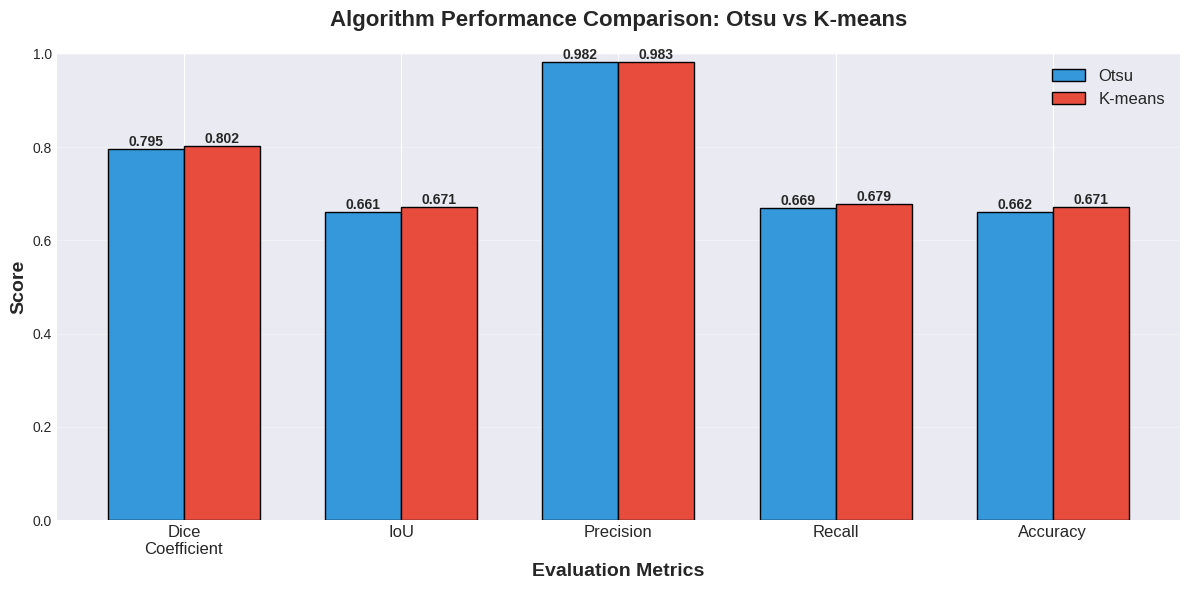


[2/5] Creating metrics per image plots...
✓ Saved: figure2_metrics_per_image.png


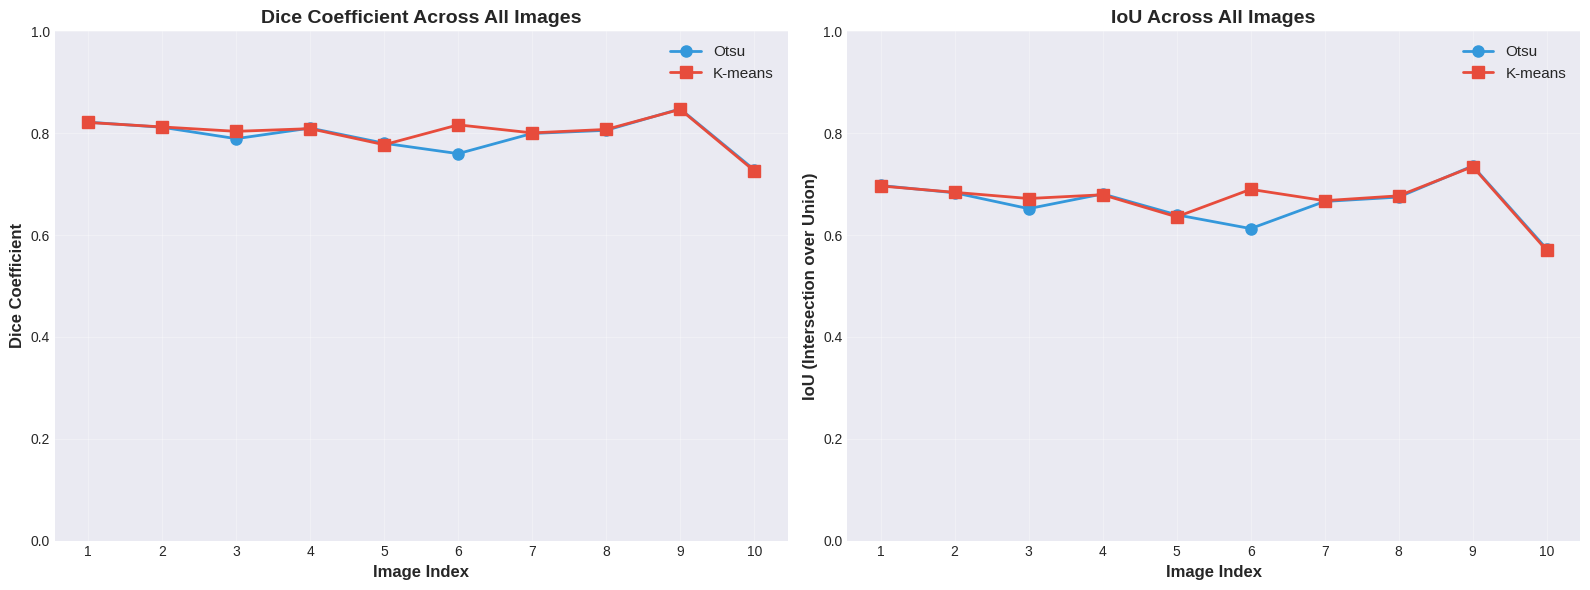


[3/5] Creating sample segmentation results...
✓ Saved: figure3_segmentation_samples.png


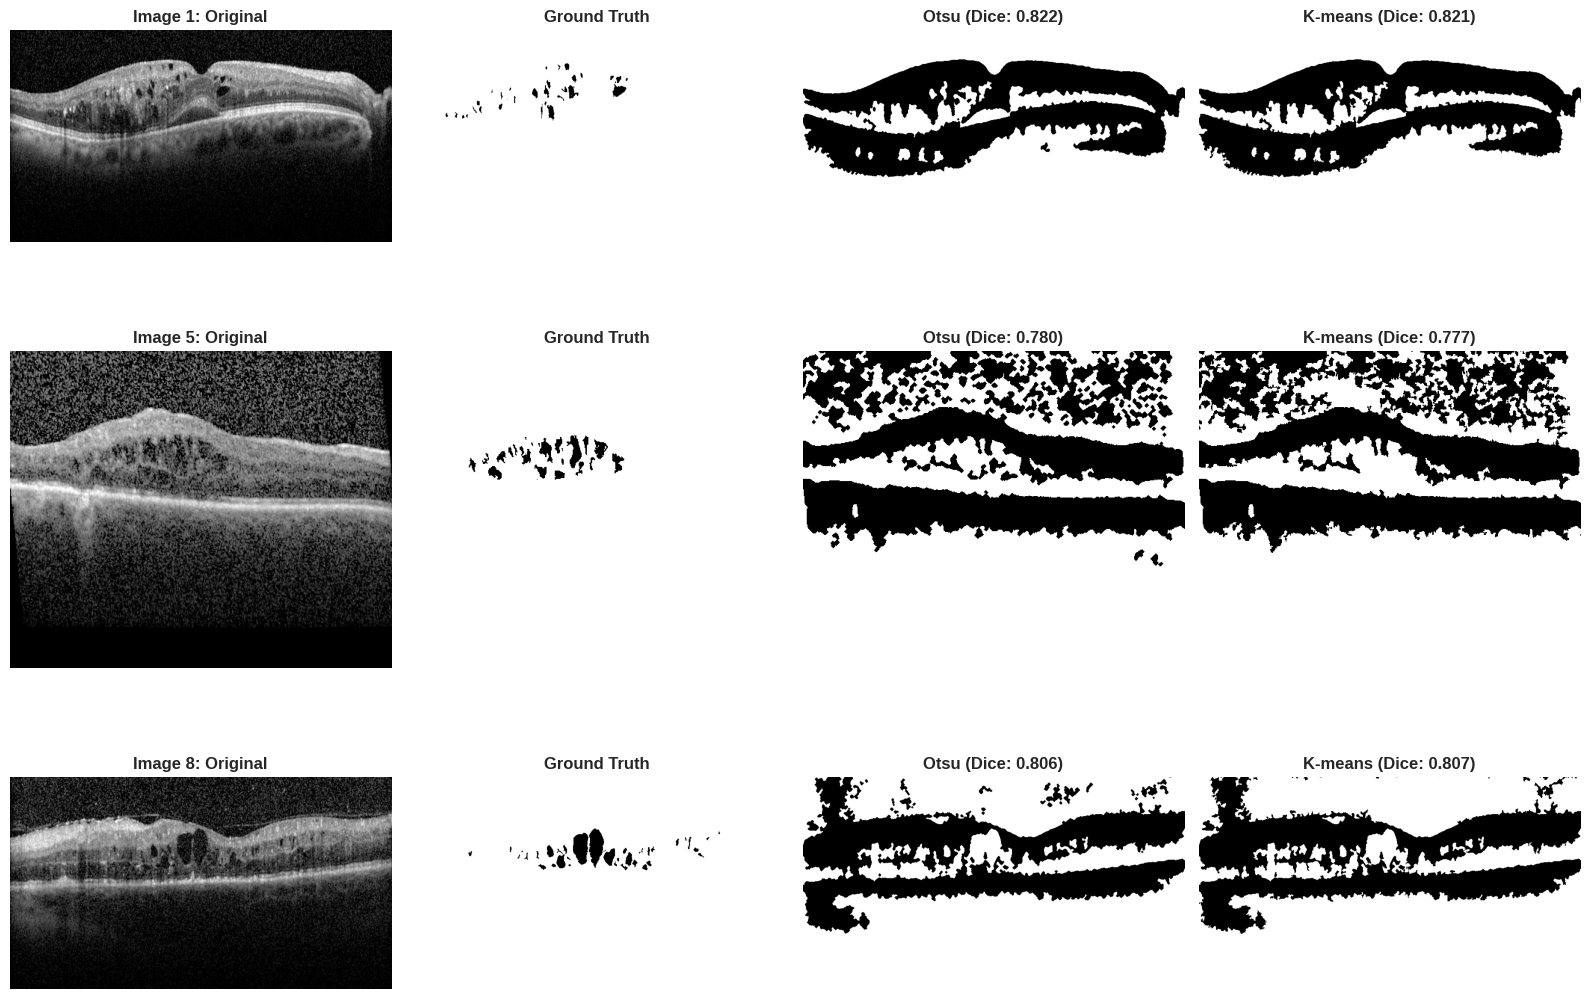


[4/5] Creating overlay comparison...
✓ Saved: figure4_overlay_comparison.png


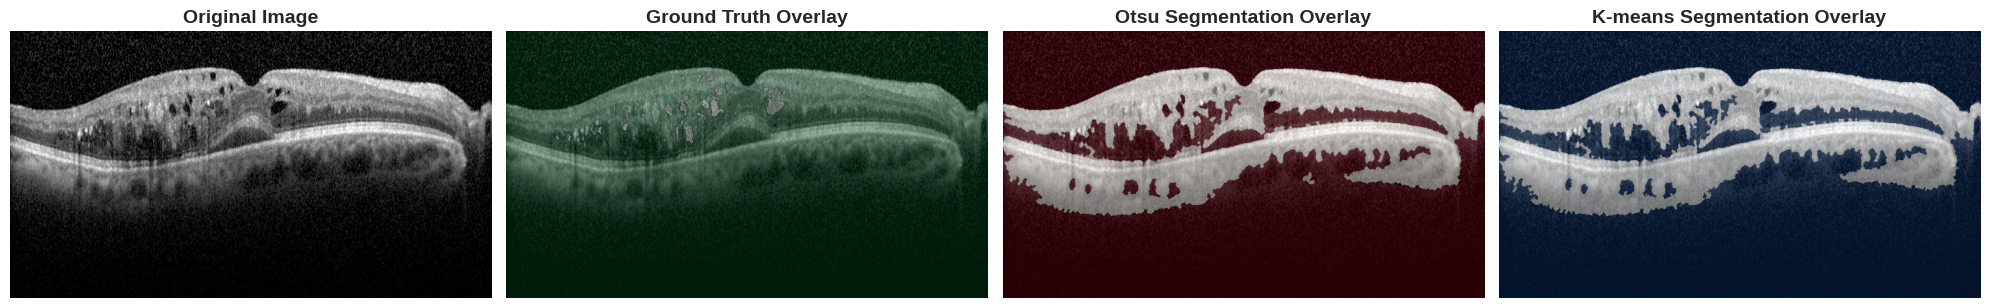


[5/5] Creating statistical distribution boxplot...
✓ Saved: figure5_metrics_boxplot.png


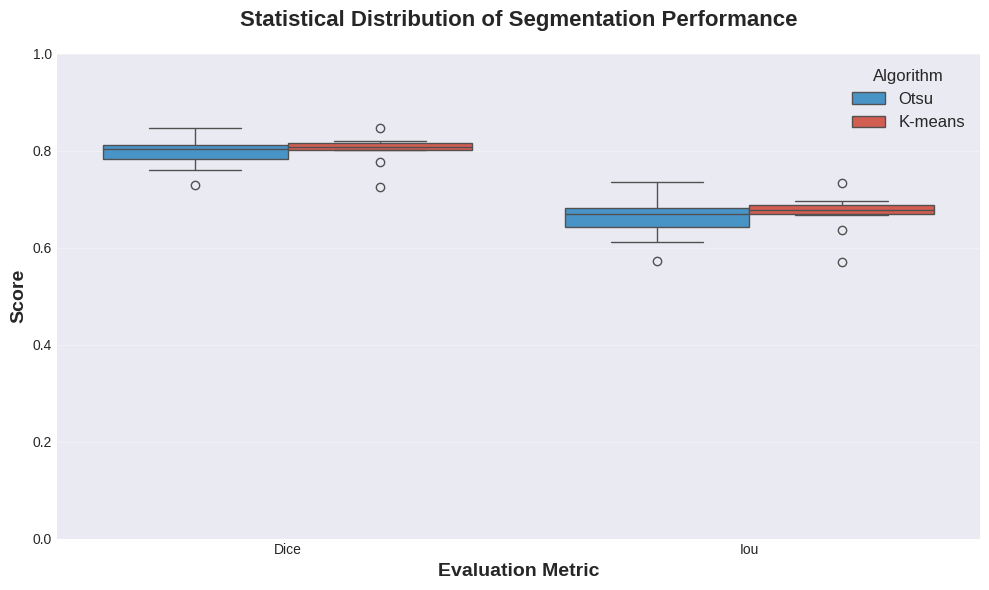


✓ ALL FIGURES GENERATED SUCCESSFULLY!

Files saved:
  • figure1_algorithm_comparison.png
  • figure2_metrics_per_image.png
  • figure3_segmentation_samples.png
  • figure4_overlay_comparison.png
  • figure5_metrics_boxplot.png

These are ready to insert into your report!


In [ ]:
# GENERATE ALL VISUALIZATIONS

generate_all_report_figures(paired_image_paths, paired_mask_paths, results, summary_df)
